# Vector Store Debug Notebook

This notebook helps debug RAG retrieval issues by:
1. Querying vector stores and examining similarity scores
2. Testing similarity against different metadata fields (title, project name, etc.)
3. Comparing chunk-level vs project-level retrieval

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
from pathlib import Path

from rag.vectorstore import VectorStore
from rag.project_vectorstore import ProjectVectorStore
from rag.embeddings import EmbeddingManager

print("Imports successful!")

/Users/bruengw/Library/CloudStorage/OneDrive-AbbVieInc(O365)/Documents/confluence_rag/.conf_rag/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-11 14:10:47.060 | INFO     | rag.query_processor:<module>:42 - NLTK loaded successfully for query processing


Imports successful!


## Configuration

In [7]:
# === CONFIGURATION ===

# Which vector store to query: 'chunks' or 'projects'
STORE_TYPE = 'chunks'  # Change to 'projects' to query project store

# Number of results to retrieve
TOP_K = 20

# Paths
CHUNK_STORE_PATH = "../Data_Storage/vector_db"
PROJECT_STORE_PATH = "../Data_Storage/project_vector_db"

## Load Vector Stores

In [4]:
# Initialize embedding manager
embedding_manager = EmbeddingManager()
print(f"Embedding model: {embedding_manager.model_name}")
print(f"Embedding dimension: {embedding_manager.embedding_dimension}")

2026-03-11 14:11:09.170 | INFO     | rag.embeddings:__init__:26 - Loading embedding model: all-MiniLM-L6-v2
2026-03-11 14:11:11.504 | INFO     | rag.embeddings:__init__:29 - Embedding model loaded. Dimension: 384


Embedding model: all-MiniLM-L6-v2
Embedding dimension: 384


In [5]:
# Load chunk vector store
chunk_store = VectorStore(persist_directory=CHUNK_STORE_PATH)
print(f"Chunk store loaded: {chunk_store.count()} chunks")
print(f"Embeddings shape: {chunk_store.embeddings.shape}")

2026-03-11 14:11:14.196 | INFO     | rag.vectorstore:__init__:44 - Initializing VectorStore at: ../Data_Storage/vector_db
2026-03-11 14:11:14.246 | INFO     | rag.vectorstore:_load_or_initialize:71 - Loaded 13879 documents from disk
2026-03-11 14:11:14.246 | INFO     | rag.vectorstore:__init__:52 - Vector store initialized with collection: confluence_docs
2026-03-11 14:11:14.246 | DEBUG    | rag.vectorstore:count:429 - Vector store contains 13879 documents


Chunk store loaded: 13879 chunks
Embeddings shape: (13879, 384)


In [6]:
# Load project vector store
project_store = ProjectVectorStore(persist_directory=PROJECT_STORE_PATH)
print(f"Project store loaded: {project_store.count()} projects")
print(f"Embeddings shape: {project_store.embeddings.shape}")
print(f"\nProjects in store:")
for name in project_store.get_project_names():
    print(f"  - {name}")

2026-03-11 14:11:16.092 | INFO     | rag.project_vectorstore:_load_or_initialize:109 - Loaded 143 projects from disk
2026-03-11 14:11:16.092 | INFO     | rag.project_vectorstore:__init__:86 - Initialized ProjectVectorStore (dir=../Data_Storage/project_vector_db, model=all-MiniLM-L6-v2)


Project store loaded: 143 projects
Embeddings shape: (143, 384)

Projects in store:
  - ASML/GSML
  - ATLAS
  - ATOMS
  - ATOMS AD Subtyping Analysis
  - ATOMS GEA Subtyping Analysis
  - ATOMS HS LUTI Network Analysis
  - ATOMS HS Subtyping Analysis
  - ATOMS NSCLC Subtyping Analysis
  - Ad-Stock Non-Linear Mixed Modeling
  - Automate and fine-tune Jarvis Dashboard checks
  - BEx Aesthetics Portfolio Management Project
  - CAMPAIGN Project Template
  - CAP - APEX Project
  - CARIS Overall Survival prediction and patient prognostic subtyping
  - CDSO - Continuous Data Review (CDR)
  - CDSO - Operational Insight & Performance (OIP)
  - CDSO - Operations Intelligence Tool (OIT)
  - CDSO Rollup Smartsheet
  - CLOVER
  - CLOVERX Project
  - COMET
  - CRA Pre-Visit Summary
  - CSC - Global Site Survey (GSS)
  - CSC - Microsurvey Support
  - CSM CRM Enhancement - V2.0
  - CSM Pipeline Feature Store
  - Catalyst
  - Catalyst - Fix the confidence interval calculation methodology
  - Catalyst Co

---
## Section 1: Query Vector Store with Detailed Similarity Scores

In [8]:
def query_with_details(query: str, store_type: str = 'chunks', top_k: int = 10):
    """
    Query vector store and return detailed similarity information.
    
    Args:
        query: Search query
        store_type: 'chunks' or 'projects'
        top_k: Number of results to return
    """
    print(f"{'='*80}")
    print(f"QUERY: {query}")
    print(f"STORE: {store_type}")
    print(f"TOP_K: {top_k}")
    print(f"{'='*80}\n")
    
    # Generate query embedding
    query_embedding = embedding_manager.generate_embedding(query)
    print(f"Query embedding shape: {query_embedding.shape}")
    print(f"Query embedding norm: {np.linalg.norm(query_embedding):.4f}")
    print()
    
    # Select store
    if store_type == 'chunks':
        store = chunk_store
        embeddings = store.embeddings
        metadatas = store.metadatas
        documents = store.documents
    else:
        store = project_store
        embeddings = store.embeddings
        metadatas = store.metadatas
        documents = store.documents
    
    # Compute cosine similarity
    query_norm = query_embedding / (np.linalg.norm(query_embedding) + 1e-10)
    embedding_norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-10
    normalized_embeddings = embeddings / embedding_norms
    similarities = np.dot(normalized_embeddings, query_norm)
    
    # Statistics
    print(f"Similarity Statistics:")
    print(f"  Min:  {similarities.min():.6f}")
    print(f"  Max:  {similarities.max():.6f}")
    print(f"  Mean: {similarities.mean():.6f}")
    print(f"  Std:  {similarities.std():.6f}")
    print()
    
    # Get top-k indices
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    # Build results dataframe
    results = []
    for rank, idx in enumerate(top_indices, 1):
        meta = metadatas[idx]
        sim = similarities[idx]
        doc_preview = documents[idx][:200].replace('\n', ' ')
        
        result = {
            'rank': rank,
            'similarity': sim,
            'distance': 1 - sim,
        }
        
        if store_type == 'chunks':
            result.update({
                'title': meta.get('title', 'N/A')[:50],
                'main_project': meta.get('main_project', 'N/A'),
                'chunk_index': meta.get('chunk_index', 'N/A'),
                'depth': meta.get('depth', 'N/A'),
                'content_preview': doc_preview,
            })
        else:
            result.update({
                'main_project': meta.get('main_project', 'N/A'),
                'page_count': meta.get('page_count', 0),
                'content_preview': doc_preview,
            })
        
        results.append(result)
    
    df = pd.DataFrame(results)
    return df, similarities

In [10]:
# Test query
QUERY = "What is ALFA?"
QUERY = "Describe in detail the atlas project architecture"

# Run query against selected store
results_df, all_similarities = query_with_details(QUERY, store_type=STORE_TYPE, top_k=TOP_K)

# Display results
pd.set_option('display.max_colwidth', 100)
results_df

QUERY: Describe in detail the atlas project architecture
STORE: chunks
TOP_K: 20



2026-03-11 14:12:25.899 | DEBUG    | rag.embeddings:generate_embedding:46 - Generated embedding for text of length 49


Query embedding shape: (384,)
Query embedding norm: 1.0000

Similarity Statistics:
  Min:  -0.124602
  Max:  0.677878
  Mean: 0.176460
  Std:  0.109722



,rank,similarity,distance,title,main_project,chunk_index,depth,content_preview
0,1,0.677878,0.322122,5.7.1 Operation Runbook,N/A,N/A,N/A,This is the ATLAS Runbook or User Guide.
1,2,0.530518,0.469482,15.1 ATLAS Project Charter,"DSA Impact, Design, and Experimental AI",N/A,6,Project Charter Definition and Purpose: To provide minor updates to the currently deployed ATLAS...
2,3,0.530518,0.469482,15.1 ATLAS Project Charter,N/A,N/A,N/A,Project Charter Definition and Purpose: To provide minor updates to the currently deployed ATLAS...
3,4,0.530518,0.469482,15.1 ATLAS Project Charter,"DSA Impact, Design, and Experimental AI",N/A,6,Project Charter Definition and Purpose: To provide minor updates to the currently deployed ATLAS...
4,5,0.530518,0.469482,15.1 ATLAS Project Charter,N/A,N/A,N/A,Project Charter Definition and Purpose: To provide minor updates to the currently deployed ATLAS...
5,6,0.530518,0.469482,15.1 ATLAS Project Charter,"DSA Impact, Design, and Experimental AI",N/A,6,Project Charter Definition and Purpose: To provide minor updates to the currently deployed ATLAS...
6,7,0.530518,0.469482,15.1 ATLAS Project Charter,N/A,N/A,N/A,Project Charter Definition and Purpose: To provide minor updates to the currently deployed ATLAS...
7,8,0.530066,0.469934,2. CDSO Smartsheet Optimization,N/A,N/A,N/A,Recommended structure under the projects true
8,9,0.530066,0.469934,3. HLM App,N/A,N/A,N/A,Recommended structure under the projects true
9,10,0.530066,0.469934,1. RBQM,N/A,N/A,N/A,Recommended structure under the projects true


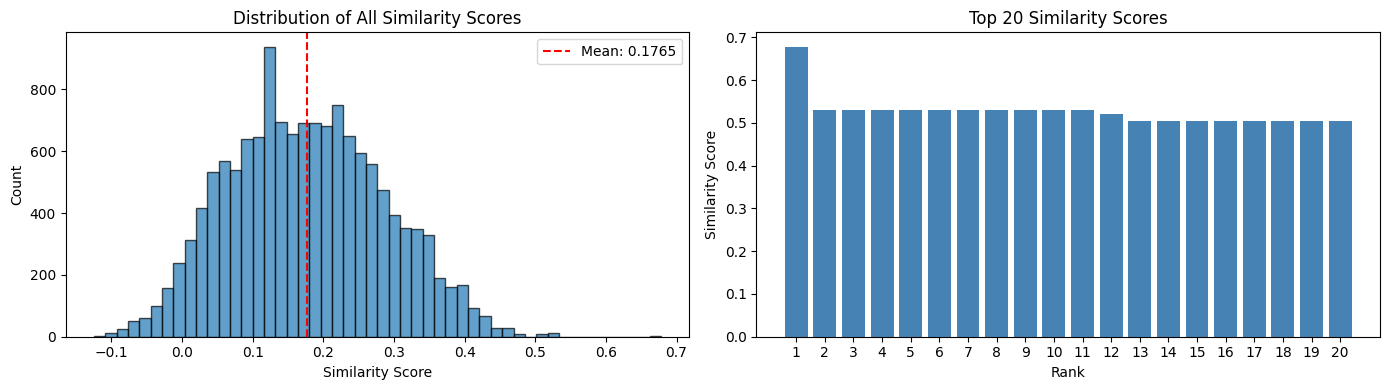

In [12]:
# Visualize similarity distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of all similarities
axes[0].hist(all_similarities, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Similarity Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of All Similarity Scores')
axes[0].axvline(x=all_similarities.mean(), color='red', linestyle='--', label=f'Mean: {all_similarities.mean():.4f}')
axes[0].legend()

# Top-k similarities
axes[1].bar(range(len(results_df)), results_df['similarity'], color='steelblue')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Similarity Score')
axes[1].set_title(f'Top {TOP_K} Similarity Scores')
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels(range(1, len(results_df) + 1))

plt.tight_layout()
plt.show()

---
## Section 2: Compare Similarity Against Different Metadata Fields

Test if searching against page titles or project names yields better results than content.

In [17]:
def compute_similarity_to_field(query: str, field_name: str, store_type: str = 'chunks'):
    """
    Compute similarity between query and a specific metadata field.
    
    Args:
        query: Search query
        field_name: Metadata field to compare against (e.g., 'title', 'main_project')
        store_type: 'chunks' or 'projects'
    """
    # Select store
    if store_type == 'chunks':
        metadatas = chunk_store.metadatas
    else:
        metadatas = project_store.metadatas
    
    # Extract field values
    field_values = [meta.get(field_name, '') or '' for meta in metadatas]
    unique_values = list(set(v for v in field_values if v))
    
    print(f"Field: {field_name}")
    print(f"Unique values: {len(unique_values)}")
    print(f"Sample values: {unique_values[:10]}")
    print()
    
    # Generate query embedding
    query_embedding = embedding_manager.generate_embedding(query)
    
    # Generate embeddings for unique field values
    if not unique_values:
        print("No values found for this field!")
        return None
    
    print(f"Generating embeddings for {len(unique_values)} unique {field_name} values...")
    field_embeddings = embedding_manager.generate_embeddings(unique_values)
    
    # Compute similarities
    query_norm = query_embedding / (np.linalg.norm(query_embedding) + 1e-10)
    field_norms = np.linalg.norm(field_embeddings, axis=1, keepdims=True) + 1e-10
    normalized_field_embeddings = field_embeddings / field_norms
    similarities = np.dot(normalized_field_embeddings, query_norm)
    
    # Create results dataframe
    results = []
    for i, (value, sim) in enumerate(zip(unique_values, similarities)):
        results.append({
            field_name: value,
            'similarity': sim,
        })
    
    df = pd.DataFrame(results).sort_values('similarity', ascending=False).reset_index(drop=True)
    df.index = df.index + 1  # 1-indexed rank
    df.index.name = 'rank'
    
    return df

In [16]:
QUERY = "What is the statistical method used in the ALFA project?"

In [18]:
# Test query against page TITLES
print("=" * 80)
print(f"COMPARING QUERY TO PAGE TITLES")
print(f"Query: {QUERY}")
print("=" * 80)
print()

title_similarities = compute_similarity_to_field(QUERY, 'title', store_type='chunks')
if title_similarities is not None:
    print("\nTop 20 most similar titles:")
    display(title_similarities.head(20))

COMPARING QUERY TO PAGE TITLES
Query: What is the statistical method used in the ALFA project?

Field: title
Unique values: 1559
Sample values: ['2.1 Clover 2.0 Project - Weekly Sync 2025-07-18', 'RWD Challenge Tracker', '12.9 Clarifications', 'InsightQ AI', '0. Project Template', '3.0 - DE Request Portal', '15.1 Site-Capacity', '12.1 Project Charter', '8.6.1 Operation Runbook', 'BPA Sprint 16 2025']



2026-03-11 14:20:15.488 | DEBUG    | rag.embeddings:generate_embedding:46 - Generated embedding for text of length 56
2026-03-11 14:20:15.489 | INFO     | rag.embeddings:generate_embeddings:67 - Generating embeddings for 1559 texts


Generating embeddings for 1559 unique title values...


Batches: 100%|██████████| 49/49 [00:00<00:00, 74.22it/s]
2026-03-11 14:20:16.159 | INFO     | rag.embeddings:generate_embeddings:76 - Generated 1559 embeddings



Top 20 most similar titles:


,title,similarity
rank,,
1,Model/Methodology,0.473403
2,12.7.1 Methodology & Lab Data Relationship,0.459259
3,5. RISE-AI - IA - Statistical Methods,0.454758
4,4. Models/Methodology,0.450773
5,5. Methodology/Approach,0.433849
6,11.2 Research/Methodology,0.429115
7,2. Methodology,0.426498
8,11.2. Methodology,0.408273
9,20.4 Methodology / Approach,0.401461


In [20]:
# Test query against MAIN_PROJECT names
print("=" * 80)
print(f"COMPARING QUERY TO MAIN_PROJECT NAMES")
print(f"Query: {QUERY}")
print("=" * 80)
print()

project_similarities = compute_similarity_to_field(QUERY, 'main_project', store_type='chunks')
if project_similarities is not None:
    print("\nAll projects ranked by similarity:")
    display(project_similarities)

2026-03-11 14:20:46.335 | DEBUG    | rag.embeddings:generate_embedding:46 - Generated embedding for text of length 56
2026-03-11 14:20:46.335 | INFO     | rag.embeddings:generate_embeddings:67 - Generating embeddings for 143 texts


COMPARING QUERY TO MAIN_PROJECT NAMES
Query: What is the statistical method used in the ALFA project?

Field: main_project
Unique values: 143
Sample values: ['CLOVER', 'DSA Trial Execution', 'Patient Support Program', 'ATOMS HS LUTI Network Analysis', 'CARIS Overall Survival prediction and patient prognostic subtyping', 'Code Documentation Tool', 'ATLAS', 'RISE-AI - Resource Planning', 'PRISM- Proactive Reporting and Insight Management', 'RISE-AI - Engagement Monitoring']

Generating embeddings for 143 unique main_project values...


Batches: 100%|██████████| 5/5 [00:00<00:00, 51.49it/s]
2026-03-11 14:20:46.435 | INFO     | rag.embeddings:generate_embeddings:76 - Generated 143 embeddings



All projects ranked by similarity:


,main_project,similarity
rank,,
1,IBD RT project,0.318775
2,GCA project,0.317363
3,Publication Efficacy Extraction,0.305726
4,Exploratory data analysis to generate evidence,0.297761
5,Generating realistic Catalyst M2 enrollment timelines,0.289567
...,...,...
139,Claude Ruleset,-0.026974
140,CSM Pipeline Feature Store,-0.034607
141,Patient Discontinuation,-0.037485


---
## Section 3: Side-by-Side Comparison of Content vs Title Similarity

In [ ]:
def compare_content_vs_title_retrieval(query: str, top_k: int = 10):
    """
    Compare what gets retrieved when searching content embeddings vs title embeddings.
    """
    print(f"Query: {query}")
    print(f"="*80)
    
    # Generate query embedding
    query_embedding = embedding_manager.generate_embedding(query)
    query_norm = query_embedding / (np.linalg.norm(query_embedding) + 1e-10)
    
    # --- Content-based similarity (existing embeddings) ---
    content_embeddings = chunk_store.embeddings
    content_norms = np.linalg.norm(content_embeddings, axis=1, keepdims=True) + 1e-10
    normalized_content = content_embeddings / content_norms
    content_similarities = np.dot(normalized_content, query_norm)
    
    # --- Title-based similarity (compute on the fly) ---
    titles = [meta.get('title', '') or '' for meta in chunk_store.metadatas]
    print(f"Generating title embeddings for {len(titles)} chunks...")
    title_embeddings = embedding_manager.generate_embeddings(titles)
    title_norms = np.linalg.norm(title_embeddings, axis=1, keepdims=True) + 1e-10
    normalized_titles = title_embeddings / title_norms
    title_similarities = np.dot(normalized_titles, query_norm)
    
    # --- Combined similarity ---
    # Weight: 0.5 content + 0.5 title
    combined_similarities = 0.5 * content_similarities + 0.5 * title_similarities
    
    # Get top-k for each method
    content_top = np.argsort(content_similarities)[::-1][:top_k]
    title_top = np.argsort(title_similarities)[::-1][:top_k]
    combined_top = np.argsort(combined_similarities)[::-1][:top_k]
    
    # Build comparison dataframe
    comparison = []
    for rank in range(top_k):
        content_idx = content_top[rank]
        title_idx = title_top[rank]
        combined_idx = combined_top[rank]
        
        comparison.append({
            'rank': rank + 1,
            'content_title': chunk_store.metadatas[content_idx].get('title', '')[:40],
            'content_project': chunk_store.metadatas[content_idx].get('main_project', ''),
            'content_sim': f"{content_similarities[content_idx]:.4f}",
            'title_title': chunk_store.metadatas[title_idx].get('title', '')[:40],
            'title_project': chunk_store.metadatas[title_idx].get('main_project', ''),
            'title_sim': f"{title_similarities[title_idx]:.4f}",
            'combined_title': chunk_store.metadatas[combined_idx].get('title', '')[:40],
            'combined_project': chunk_store.metadatas[combined_idx].get('main_project', ''),
            'combined_sim': f"{combined_similarities[combined_idx]:.4f}",
        })
    
    return pd.DataFrame(comparison)

In [ ]:
# Compare retrieval methods
comparison_df = compare_content_vs_title_retrieval(QUERY, top_k=10)

print("\nContent-based retrieval:")
display(comparison_df[['rank', 'content_title', 'content_project', 'content_sim']])

print("\nTitle-based retrieval:")
display(comparison_df[['rank', 'title_title', 'title_project', 'title_sim']])

print("\nCombined (50/50) retrieval:")
display(comparison_df[['rank', 'combined_title', 'combined_project', 'combined_sim']])

---
## Section 4: Investigate Specific Project/Document

In [ ]:
def find_chunks_by_project(project_name: str, query: str = None):
    """
    Find all chunks belonging to a specific project and optionally compute similarity.
    """
    matching_indices = []
    for i, meta in enumerate(chunk_store.metadatas):
        if meta.get('main_project', '').lower() == project_name.lower():
            matching_indices.append(i)
    
    print(f"Found {len(matching_indices)} chunks for project: {project_name}")
    
    if not matching_indices:
        # Try partial match
        for i, meta in enumerate(chunk_store.metadatas):
            if project_name.lower() in meta.get('main_project', '').lower():
                matching_indices.append(i)
        print(f"Partial match found {len(matching_indices)} chunks")
    
    if not matching_indices:
        return None
    
    # Compute similarity if query provided
    if query:
        query_embedding = embedding_manager.generate_embedding(query)
        query_norm = query_embedding / (np.linalg.norm(query_embedding) + 1e-10)
        
        embeddings = chunk_store.embeddings[matching_indices]
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-10
        normalized = embeddings / norms
        similarities = np.dot(normalized, query_norm)
    else:
        similarities = [None] * len(matching_indices)
    
    # Build results
    results = []
    for i, idx in enumerate(matching_indices):
        meta = chunk_store.metadatas[idx]
        results.append({
            'chunk_index': meta.get('chunk_index', 'N/A'),
            'title': meta.get('title', 'N/A')[:50],
            'depth': meta.get('depth', 'N/A'),
            'similarity': similarities[i] if query else None,
            'content_preview': chunk_store.documents[idx][:150].replace('\n', ' '),
        })
    
    df = pd.DataFrame(results)
    if query:
        df = df.sort_values('similarity', ascending=False)
    return df

In [ ]:
# Find chunks for a specific project
TARGET_PROJECT = "ALFA"  # Change this to investigate a specific project

project_chunks = find_chunks_by_project(TARGET_PROJECT, query=QUERY)
if project_chunks is not None:
    print(f"\nChunks for '{TARGET_PROJECT}' ranked by similarity to '{QUERY}':")
    display(project_chunks)

---
## Section 5: Check for Embedding Issues

In [ ]:
def diagnose_embeddings(store_type: str = 'chunks'):
    """Check for common embedding issues."""
    
    if store_type == 'chunks':
        embeddings = chunk_store.embeddings
        name = "Chunk Store"
    else:
        embeddings = project_store.embeddings
        name = "Project Store"
    
    print(f"Diagnosing {name}")
    print("=" * 50)
    print(f"Shape: {embeddings.shape}")
    print(f"Dtype: {embeddings.dtype}")
    print()
    
    # Check for NaN/Inf
    nan_count = np.isnan(embeddings).sum()
    inf_count = np.isinf(embeddings).sum()
    print(f"NaN values: {nan_count}")
    print(f"Inf values: {inf_count}")
    print()
    
    # Check norms
    norms = np.linalg.norm(embeddings, axis=1)
    print(f"Embedding norms:")
    print(f"  Min:  {norms.min():.6f}")
    print(f"  Max:  {norms.max():.6f}")
    print(f"  Mean: {norms.mean():.6f}")
    print(f"  Std:  {norms.std():.6f}")
    print()
    
    # Check for zero vectors
    zero_vectors = (norms < 1e-6).sum()
    print(f"Zero/near-zero vectors: {zero_vectors}")
    
    # Check for duplicate embeddings
    unique_count = len(np.unique(embeddings, axis=0))
    duplicate_count = len(embeddings) - unique_count
    print(f"Duplicate embeddings: {duplicate_count}")
    print()
    
    # Sample pairwise similarities
    n_samples = min(100, len(embeddings))
    sample_indices = np.random.choice(len(embeddings), n_samples, replace=False)
    sample_embeddings = embeddings[sample_indices]
    
    # Normalize
    sample_norms = np.linalg.norm(sample_embeddings, axis=1, keepdims=True) + 1e-10
    normalized_samples = sample_embeddings / sample_norms
    
    # Pairwise similarity matrix
    similarity_matrix = np.dot(normalized_samples, normalized_samples.T)
    
    # Get upper triangle (excluding diagonal)
    upper_tri = similarity_matrix[np.triu_indices(n_samples, k=1)]
    
    print(f"Pairwise similarities (sample of {n_samples}):")
    print(f"  Min:  {upper_tri.min():.6f}")
    print(f"  Max:  {upper_tri.max():.6f}")
    print(f"  Mean: {upper_tri.mean():.6f}")
    print(f"  Std:  {upper_tri.std():.6f}")
    
    if upper_tri.std() < 0.01:
        print("\n⚠️  WARNING: Very low variance in similarities - embeddings may be too similar!")
    
    return norms, similarity_matrix

In [ ]:
# Diagnose chunk store
chunk_norms, chunk_sim_matrix = diagnose_embeddings('chunks')

In [ ]:
# Diagnose project store
project_norms, project_sim_matrix = diagnose_embeddings('projects')

---
## Section 6: Interactive Query Testing

In [ ]:
# Quick test function - change query and run
def quick_test(query: str, top_k: int = 5):
    """Quick test against both stores."""
    print(f"Query: {query}")
    print("="*60)
    
    # Project store
    print("\n--- PROJECT STORE ---")
    results = project_store.query_projects(query, n_results=top_k)
    for i, r in enumerate(results, 1):
        print(f"  {i}. {r['main_project']}: sim={r['similarity']:.4f}")
    
    # Chunk store
    print("\n--- CHUNK STORE ---")
    results = chunk_store.query(query, n_results=top_k)
    for i in range(len(results['documents'])):
        meta = results['metadatas'][i]
        dist = results['distances'][i]
        print(f"  {i+1}. {meta.get('title', 'N/A')[:40]}")
        print(f"      project={meta.get('main_project', 'N/A')}, dist={dist:.4f}")

In [ ]:
# Test various queries
test_queries = [
    "What is ALFA?",
    "ALFA project",
    "Tell me about the ALFA project",
    "data pipeline",
    "machine learning",
]

for q in test_queries:
    quick_test(q, top_k=3)
    print("\n")